In [149]:
#0
import numpy as np
import pandas as pd

from pathlib import Path
import json
import joblib
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.compose import ColumnTransformer
from sklearn.neighbors import NearestNeighbors
from scipy.sparse import hstack
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report




In [150]:
#1
DATASET_PATH = Path("CaloriX_Nutrition_Dataset.csv")

df = pd.read_csv(DATASET_PATH)

print(df.shape)

df.head()

(8094, 23)


,food_id,food_name,category,serving_size_g,calories,protein_g,carbs_g,fat_g,fiber_g,sugar_g,...,potassium_mg,calcium_mg,iron_mg,magnesium_mg,phosphorus_mg,zinc_mg,vitamin_a_mcg,vitamin_c_mg,vitamin_d_mcg,vitamin_b12_mcg
0,169831,"APPLEBEE'S, 9 oz house sirloin steak",Restaurant Foods,157.0,791.0,26.85,0.00,9.08,0.0,0.00,...,350.0,16.0,2.07,24.0,202.0,5.35,7.0,0.0,0.0,2.00
1,169008,"APPLEBEE'S, Double Crunch Shrimp",Restaurant Foods,206.0,1352.0,12.31,25.96,18.90,2.6,1.07,...,97.0,45.0,1.03,23.0,271.0,0.78,2.0,0.0,0.0,0.43
2,169010,"APPLEBEE'S, KRAFT, Macaroni & Cheese, from kid...",Restaurant Foods,180.0,600.0,5.01,21.08,4.34,1.3,3.70,...,163.0,79.0,0.84,22.0,104.0,0.57,18.0,0.0,0.0,0.24
3,169841,"APPLEBEE'S, chicken tenders platter",Restaurant Foods,209.0,297.0,19.62,17.98,16.24,1.0,0.36,...,336.0,23.0,0.90,30.0,298.0,0.71,9.0,0.0,0.0,0.14
4,169012,"APPLEBEE'S, chicken tenders, from kids' menu",Restaurant Foods,99.0,1238.0,19.25,18.36,16.15,1.2,0.39,...,337.0,23.0,0.90,30.0,305.0,0.71,10.0,0.0,0.0,0.15


In [151]:
#2
print("=" * 60)

print(df.info())

print("=" * 60)

print(df.describe().T)

<class 'pandas.DataFrame'>
RangeIndex: 8094 entries, 0 to 8093
Data columns (total 23 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   food_id          8094 non-null   int64  
 1   food_name        8094 non-null   str    
 2   category         8094 non-null   str    
 3   serving_size_g   8094 non-null   float64
 4   calories         8094 non-null   float64
 5   protein_g        8094 non-null   float64
 6   carbs_g          8094 non-null   float64
 7   fat_g            8094 non-null   float64
 8   fiber_g          8094 non-null   float64
 9   sugar_g          8094 non-null   float64
 10  water_g          8094 non-null   float64
 11  cholesterol_mg   8094 non-null   float64
 12  sodium_mg        8094 non-null   float64
 13  potassium_mg     8094 non-null   float64
 14  calcium_mg       8094 non-null   float64
 15  iron_mg          8094 non-null   float64
 16  magnesium_mg     8094 non-null   float64
 17  phosphorus_mg    8094 non

In [152]:
#3
print("Missing Values")

display(df.isna().sum())

print()

print("Duplicates")

display(df.duplicated().sum())

Missing Values


food_id            0
food_name          0
category           0
serving_size_g     0
calories           0
protein_g          0
carbs_g            0
fat_g              0
fiber_g            0
sugar_g            0
water_g            0
cholesterol_mg     0
sodium_mg          0
potassium_mg       0
calcium_mg         0
iron_mg            0
magnesium_mg       0
phosphorus_mg      0
zinc_mg            0
vitamin_a_mcg      0
vitamin_c_mg       0
vitamin_d_mcg      0
vitamin_b12_mcg    0
dtype: int64


Duplicates


np.int64(0)

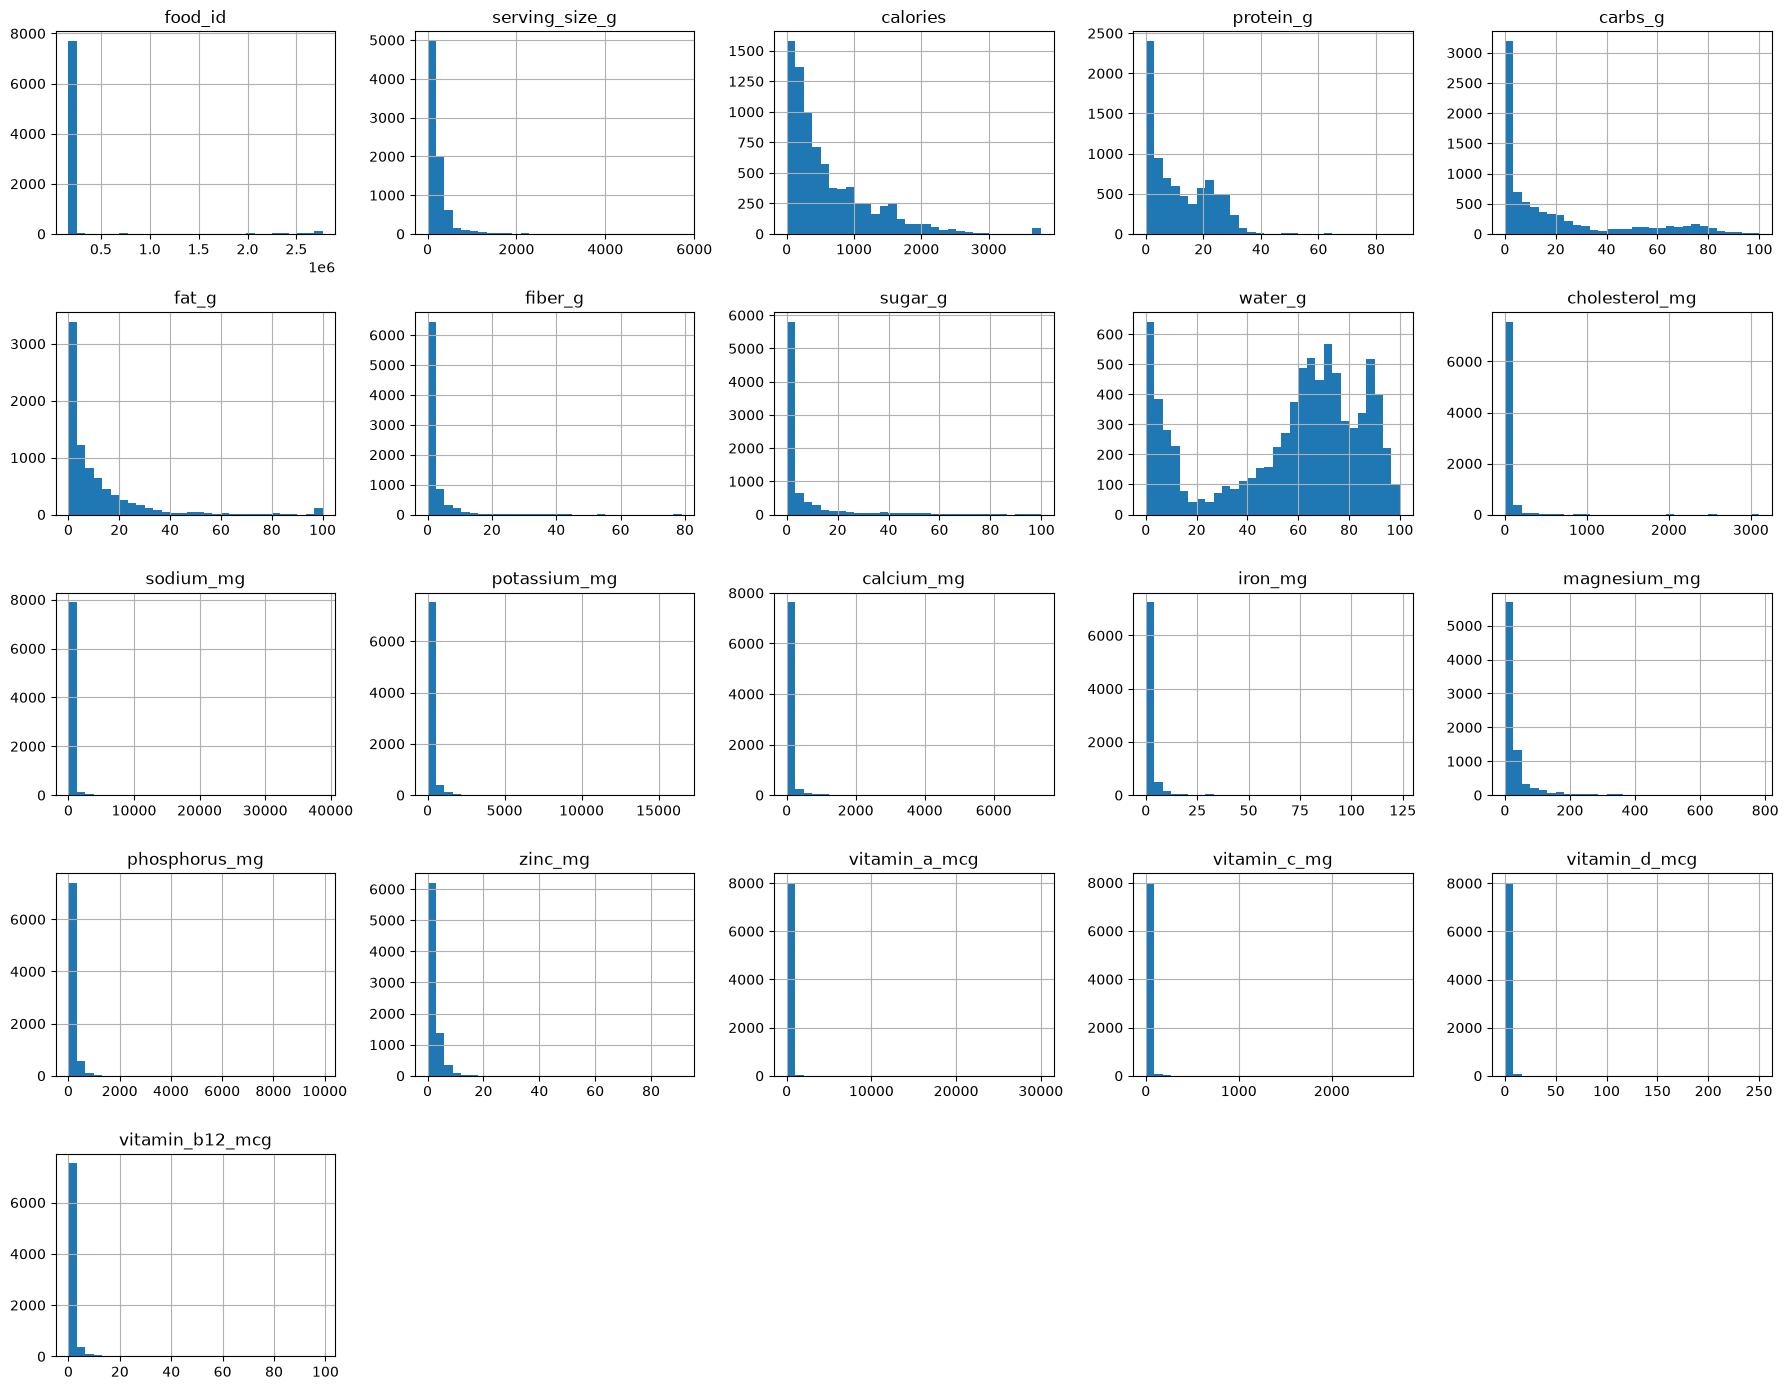

In [153]:
#4
numeric_columns = df.select_dtypes(include=np.number).columns

df[numeric_columns].hist(
    figsize=(18,14),
    bins=30
)

plt.tight_layout()

plt.show()

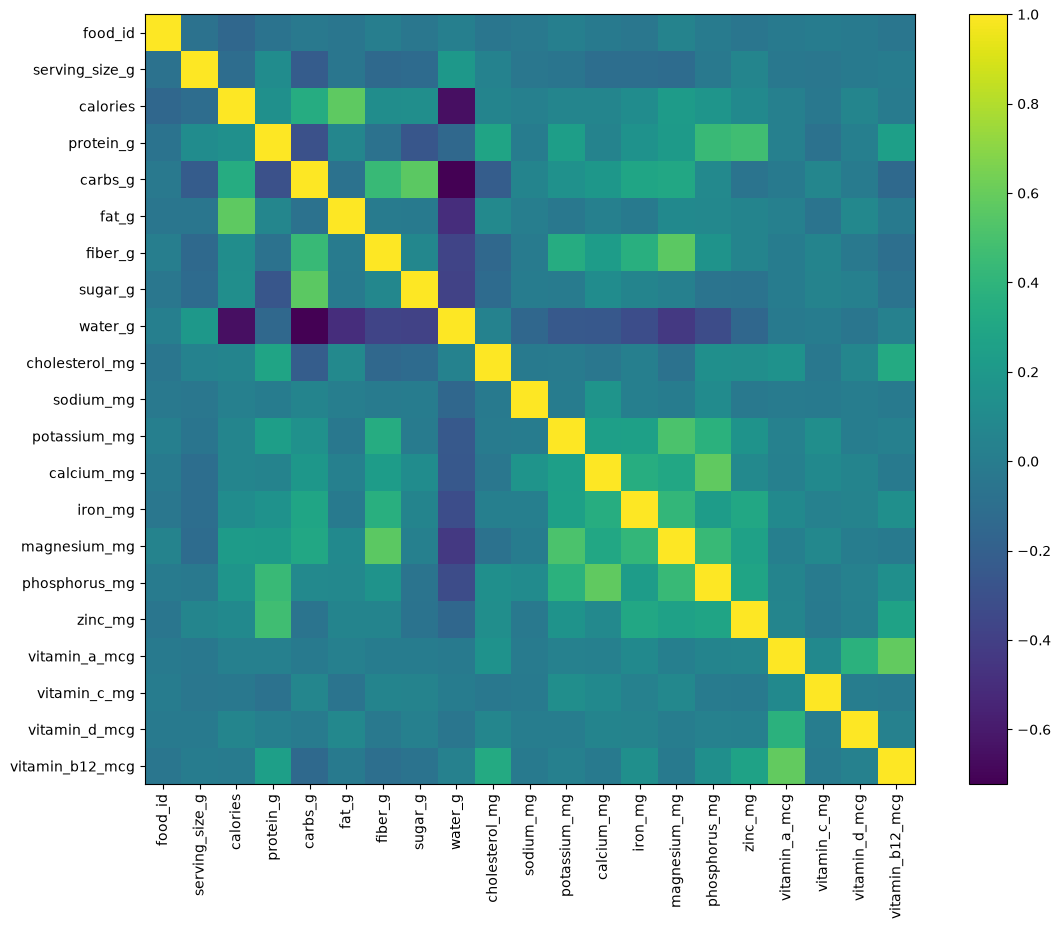

In [154]:
#5
plt.figure(figsize=(14,10))

corr = df[numeric_columns].corr()

plt.imshow(corr)

plt.xticks(
    range(len(corr.columns)),
    corr.columns,
    rotation=90
)

plt.yticks(
    range(len(corr.columns)),
    corr.columns
)

plt.colorbar()

plt.show()

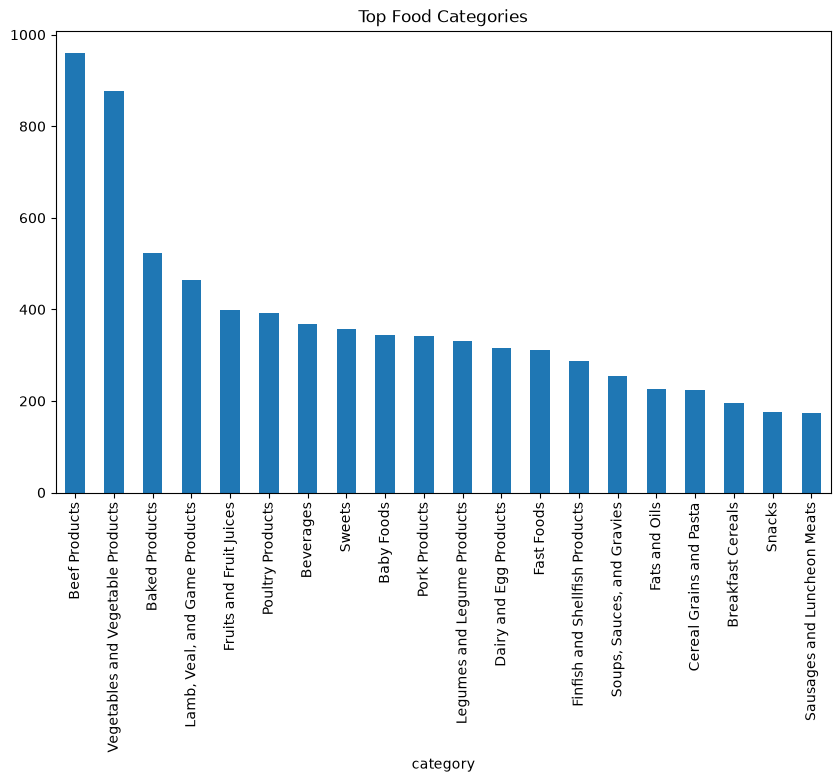

In [155]:
#6
plt.figure(figsize=(10,6))

df["category"].value_counts().head(20).plot.bar()

plt.title("Top Food Categories")

plt.show()

In [156]:
#7
print(df.columns.tolist())

['food_id', 'food_name', 'category', 'serving_size_g', 'calories', 'protein_g', 'carbs_g', 'fat_g', 'fiber_g', 'sugar_g', 'water_g', 'cholesterol_mg', 'sodium_mg', 'potassium_mg', 'calcium_mg', 'iron_mg', 'magnesium_mg', 'phosphorus_mg', 'zinc_mg', 'vitamin_a_mcg', 'vitamin_c_mg', 'vitamin_d_mcg', 'vitamin_b12_mcg']


# Feature Engineering

In [157]:
#8
feature_df = df.copy()

feature_df["calorie_density"] = (
    feature_df["calories"] /
    feature_df["serving_size_g"]
).round(3)

feature_df["protein_ratio"] = (
    feature_df["protein_g"] /
    feature_df["calories"].replace(0, 1)
).round(4)

feature_df["carb_ratio"] = (
    feature_df["carbs_g"] /
    feature_df["calories"].replace(0, 1)
).round(4)

feature_df["fat_ratio"] = (
    feature_df["fat_g"] /
    feature_df["calories"].replace(0, 1)
).round(4)

feature_df.head()

,food_id,food_name,category,serving_size_g,calories,protein_g,carbs_g,fat_g,fiber_g,sugar_g,...,phosphorus_mg,zinc_mg,vitamin_a_mcg,vitamin_c_mg,vitamin_d_mcg,vitamin_b12_mcg,calorie_density,protein_ratio,carb_ratio,fat_ratio
0,169831,"APPLEBEE'S, 9 oz house sirloin steak",Restaurant Foods,157.0,791.0,26.85,0.00,9.08,0.0,0.00,...,202.0,5.35,7.0,0.0,0.0,2.00,5.038,0.0339,0.0000,0.0115
1,169008,"APPLEBEE'S, Double Crunch Shrimp",Restaurant Foods,206.0,1352.0,12.31,25.96,18.90,2.6,1.07,...,271.0,0.78,2.0,0.0,0.0,0.43,6.563,0.0091,0.0192,0.0140
2,169010,"APPLEBEE'S, KRAFT, Macaroni & Cheese, from kid...",Restaurant Foods,180.0,600.0,5.01,21.08,4.34,1.3,3.70,...,104.0,0.57,18.0,0.0,0.0,0.24,3.333,0.0084,0.0351,0.0072
3,169841,"APPLEBEE'S, chicken tenders platter",Restaurant Foods,209.0,297.0,19.62,17.98,16.24,1.0,0.36,...,298.0,0.71,9.0,0.0,0.0,0.14,1.421,0.0661,0.0605,0.0547
4,169012,"APPLEBEE'S, chicken tenders, from kids' menu",Restaurant Foods,99.0,1238.0,19.25,18.36,16.15,1.2,0.39,...,305.0,0.71,10.0,0.0,0.0,0.15,12.505,0.0155,0.0148,0.0130


In [158]:
#9
feature_df["high_protein"] = (
    feature_df["protein_g"] >= 20
).astype(int)

feature_df["low_carb"] = (
    feature_df["carbs_g"] <= 15
).astype(int)

feature_df["high_fiber"] = (
    feature_df["fiber_g"] >= 5
).astype(int)

feature_df["low_fat"] = (
    feature_df["fat_g"] <= 5
).astype(int)

feature_df["high_sodium"] = (
    feature_df["sodium_mg"] >= 600
).astype(int)

In [159]:
#10
feature_df["text"] = (

    feature_df["food_name"].fillna("") +

    " " +

    feature_df["category"].fillna("")

)

In [160]:
#11
feature_df[
    [
        "food_name",
        "text"
    ]
].head()

,food_name,text
0,"APPLEBEE'S, 9 oz house sirloin steak","APPLEBEE'S, 9 oz house sirloin steak Restauran..."
1,"APPLEBEE'S, Double Crunch Shrimp","APPLEBEE'S, Double Crunch Shrimp Restaurant Foods"
2,"APPLEBEE'S, KRAFT, Macaroni & Cheese, from kid...","APPLEBEE'S, KRAFT, Macaroni & Cheese, from kid..."
3,"APPLEBEE'S, chicken tenders platter","APPLEBEE'S, chicken tenders platter Restaurant..."
4,"APPLEBEE'S, chicken tenders, from kids' menu","APPLEBEE'S, chicken tenders, from kids' menu R..."


In [161]:
#12
# ============================================================
# Generate meal_type labels
# ============================================================

def infer_meal_type(row):

    name = str(row["food_name"]).lower()
    category = str(row["category"]).lower()

    calories = row["calories"]
    protein = row["protein_g"]
    carbs = row["carbs_g"]
    fat = row["fat_g"]

    breakfast_keywords = [
        "egg",
        "oat",
        "cereal",
        "milk",
        "yogurt",
        "cheese",
        "toast",
        "bread",
        "pancake",
        "waffle",
        "coffee",
        "tea"
    ]

    snack_keywords = [
        "apple",
        "banana",
        "orange",
        "grape",
        "berry",
        "almond",
        "peanut",
        "cashew",
        "walnut",
        "raisin",
        "cookie",
        "cracker",
        "popcorn"
    ]

    dinner_keywords = [
        "salmon",
        "tuna",
        "shrimp",
        "fish",
        "steak",
        "beef",
        "lamb"
    ]

    for word in breakfast_keywords:
        if word in name:
            return "Breakfast"

    for word in snack_keywords:
        if word in name:
            return "Snack"

    for word in dinner_keywords:
        if word in name:
            return "Dinner"

    if calories < 180:
        return "Snack"

    if protein >= 20:
        return "Lunch"

    if fat >= 18:
        return "Dinner"

    return "Lunch"

In [162]:
#13
feature_df["meal_type"] = feature_df.apply(
    infer_meal_type,
    axis=1
)

feature_df[
    [
        "food_name",
        "meal_type"
    ]
].head(20)

,food_name,meal_type
0,"APPLEBEE'S, 9 oz house sirloin steak",Breakfast
1,"APPLEBEE'S, Double Crunch Shrimp",Snack
2,"APPLEBEE'S, KRAFT, Macaroni & Cheese, from kid...",Breakfast
3,"APPLEBEE'S, chicken tenders platter",Snack
4,"APPLEBEE'S, chicken tenders, from kids' menu",Snack
5,"APPLEBEE'S, chili",Snack
6,"APPLEBEE'S, coleslaw",Snack
7,"APPLEBEE'S, crunchy onion rings",Snack
8,"APPLEBEE'S, fish, hand battered",Snack
9,"APPLEBEE'S, french fries",Snack


In [163]:
#14
feature_df["meal_type"].value_counts()

meal_type
Lunch        2353
Snack        2092
Dinner       1849
Breakfast    1800
Name: count, dtype: int64

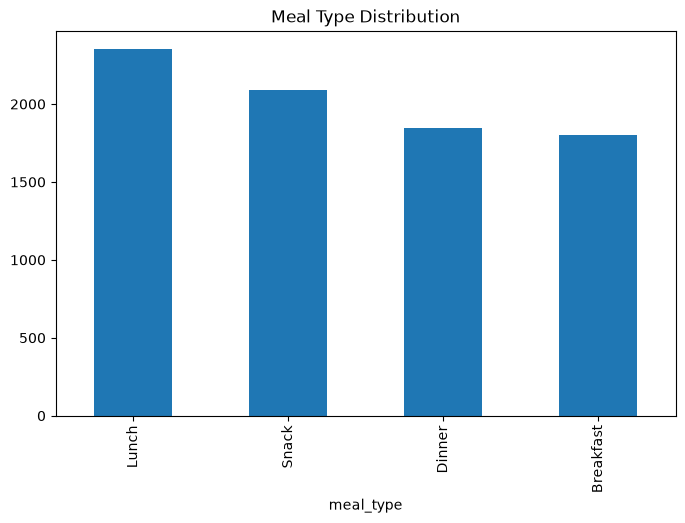

In [164]:
#15
feature_df["meal_type"].value_counts().plot.bar(figsize=(8,5))

plt.title("Meal Type Distribution")

plt.show()

In [165]:
#16
numeric_features = [
    "serving_size_g",
    "calories",
    "protein_g",
    "carbs_g",
    "fat_g",
    "protein_density",
    "fat_density",
    "carb_density",
    "calorie_density",
    "protein_ratio",
    "fat_ratio",
    "carb_ratio",
    "energy_density"
]

categorical_features = [
    "category",
    "cuisine"
]

In [166]:
feature_df["cuisine"] = "Unknown"

feature_df["protein_density"] = (
    feature_df["protein_g"] /
    feature_df["serving_size_g"].replace(0, 1)
)

feature_df["fat_density"] = (
    feature_df["fat_g"] /
    feature_df["serving_size_g"].replace(0, 1)
)

feature_df["carb_density"] = (
    feature_df["carbs_g"] /
    feature_df["serving_size_g"].replace(0, 1)
)

feature_df["energy_density"] = (
    feature_df["calories"] /
    (
        feature_df["protein_g"] +
        feature_df["carbs_g"] +
        feature_df["fat_g"]
    ).replace(0, 1)
)

feature_df["is_vegan"] = False
feature_df["is_vegetarian"] = False
feature_df["is_halal"] = False

In [167]:
required_columns = numeric_features + categorical_features

missing = [c for c in required_columns if c not in feature_df.columns]

print("Missing:", missing)

Missing: []


In [168]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numeric_features
        ),
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )
    ]
)

print("Preprocessor created.")

Preprocessor created.


In [169]:
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier

classifier_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "classifier",
            RandomForestClassifier(
                n_estimators=300,
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

print("Pipeline created.")

Pipeline created.


In [170]:


training_columns = numeric_features + categorical_features

X = feature_df[training_columns]

y = feature_df["meal_type"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(6475, 15)
(1619, 15)


In [171]:
classifier_pipeline.fit(
    X_train,
    y_train
)

print("Training completed.")

Training completed.


In [172]:
pred = classifier_pipeline.predict(X_test)

accuracy = accuracy_score(
    y_test,
    pred
)

print(f"Accuracy: {accuracy:.4f}")

print()

print(classification_report(
    y_test,
    pred
))

Accuracy: 0.8079

              precision    recall  f1-score   support

   Breakfast       0.76      0.60      0.67       360
      Dinner       0.83      0.79      0.81       370
       Lunch       0.79      0.91      0.85       471
       Snack       0.85      0.88      0.86       418

    accuracy                           0.81      1619
   macro avg       0.81      0.80      0.80      1619
weighted avg       0.81      0.81      0.80      1619



In [173]:
from pathlib import Path

MODELS_DIR = Path("models")
MODELS_DIR.mkdir(exist_ok=True)

In [174]:
import joblib

joblib.dump(
    classifier_pipeline,
    MODELS_DIR / "best_meal_classifier.pkl"
)

print("Meal classifier saved.")

Meal classifier saved.


In [175]:
scaler_bundle = {
    "preprocessor": preprocessor,
    "numeric_features": numeric_features,
    "categorical_features": categorical_features
}

joblib.dump(
    scaler_bundle,
    MODELS_DIR / "feature_scaler.pkl"
)

print("Feature scaler saved.")

Feature scaler saved.


In [176]:


feature_df["search_text"] = (

    feature_df["food_name"].fillna("") +

    " " +

    feature_df["category"].fillna("") +

    " " +

    feature_df["cuisine"].fillna("")

)

tfidf = TfidfVectorizer(

    stop_words="english",

    ngram_range=(1, 2),

    min_df=2

)

text_vectors = tfidf.fit_transform(

    feature_df["search_text"]

)

print(text_vectors.shape)

(8094, 7653)


In [177]:
nn_model = NearestNeighbors(

    metric="cosine",

    algorithm="brute",

    n_neighbors=20

)

nn_model.fit(text_vectors)

print("NearestNeighbors trained.")

NearestNeighbors trained.


In [178]:
food_recommender = {

    "tfidf": tfidf,

    "nn_model": nn_model,

    "food_frame": feature_df,

    "numeric_columns": numeric_features

}

In [179]:
joblib.dump(

    food_recommender,

    MODELS_DIR / "food_recommender.pkl"

)

print("Food recommender saved.")

Food recommender saved.


In [180]:
from sklearn.preprocessing import LabelEncoder
import joblib

label_encoder = LabelEncoder()

label_encoder.fit(feature_df["meal_type"])

joblib.dump(
    label_encoder,
    MODELS_DIR / "label_encoder.pkl"
)

print("Label encoder saved.")

Label encoder saved.


In [181]:
import json

metadata = {

    "version": "2.0",

    "dataset": "USDA Foundation + SR Legacy",

    "foods": len(feature_df),

    "feature_names": numeric_features + categorical_features,

    "feature_columns": numeric_features + categorical_features,

    "num_features": len(numeric_features + categorical_features),

    "meal_classes": label_encoder.classes_.tolist(),

    "classifier": "Pipeline(RandomForestClassifier)",

    "classifier_accuracy": float(accuracy),

    "recommendation_model": "NearestNeighbors + TF-IDF"

}

with open(
    MODELS_DIR / "metadata.json",
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        metadata,
        f,
        indent=4
    )

print("Metadata saved.")

Metadata saved.


In [182]:
feature_df.to_csv(
    MODELS_DIR / "CaloriX_Nutrition_Dataset_Clean.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Dataset saved.")

Dataset saved.


In [183]:
from pathlib import Path

print("=" * 60)

for file in sorted(Path(MODELS_DIR).iterdir()):
    print(file.name)

print("=" * 60)

best_meal_classifier.pkl
CaloriX_Nutrition_Dataset_Clean.csv
feature_scaler.pkl
food_recommender.pkl
label_encoder.pkl
metadata.json
